# 8.5 — Panorama de rough volatility

Cierra M8. **Rough volatility** (Gatheral, Jaisson, Rosenbaum, 2018) es el hallazgo
empírico de que la vol realizada es *más rugosa* que un movimiento browniano estándar —
el exponente de Hurst estimado de datos reales es $H\approx0.1$, muy por debajo de
$H=0.5$. Este notebook es un **panorama**: implementa la pieza numérica central (simular
y medir la rugosidad de un movimiento browniano fraccionario) y explica por qué el modelo
resultante (rough Bergomi) rompe los métodos semianalíticos de 8.3 — sin calibrar
rBergomi completo, que excede el alcance de un notebook introductorio.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 1. Movimiento browniano fraccionario vía el kernel de Volterra

El fBm "verdadero" (Mandelbrot-Van Ness) integra sobre $(-\infty,t]$, complicado de
simular exactamente. El proceso de **Volterra** (Riemann-Liouville) es más simple y es lo
que efectivamente usa rough Bergomi:
$$W_t^H = \int_0^t (t-s)^{H-1/2}\,dW_s$$
con $H\in(0,1)$ el exponente de Hurst — $H=1/2$ recupera el browniano estándar
($(t-s)^0=1$, kernel constante); $H<1/2$ pondera fuertemente los incrementos *recientes*
(kernel casi-singular en $s\to t$), produciendo trayectorias localmente mucho más
irregulares (rugosas) que un browniano estándar pese a tener la MISMA distribución
gaussiana en cada instante.

Se discretiza como suma de Riemann del kernel sobre una malla uniforme, con cuidado en
$s\to t$ (el kernel es integrable pero no acotado ahí).

In [2]:
def simulate_volterra_fbm(H, T, n_steps, n_paths, rng):
    '''fBm tipo Riemann-Liouville via suma de Riemann del kernel de Volterra (Seccion 1).'''
    dt = T / n_steps
    t_grid = np.linspace(dt, T, n_steps)
    dW = rng.standard_normal((n_paths, n_steps)) * np.sqrt(dt)
    W = np.zeros((n_paths, n_steps))
    for i in range(n_steps):
        t = t_grid[i]
        s_idx = np.arange(0, i + 1)
        s_mid = np.clip((s_idx + 0.5) * dt, 0.0, t - 1e-12)
        kernel = (t - s_mid) ** (H - 0.5)
        W[:, i] = dW[:, :i + 1] @ kernel
    return t_grid, W

### Demo 1 — trayectorias para varios $H$ y comparación de rugosidad

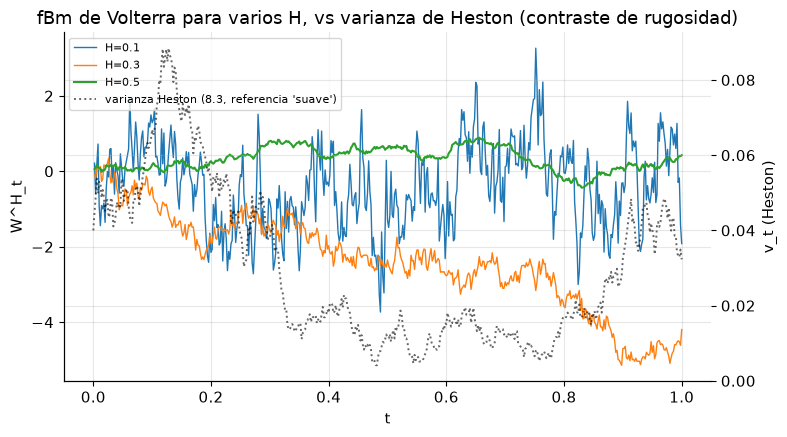

H=0.1 es visiblemente mas irregular/rugosa que H=0.5 (browniano estandar),
pese a que ambas son trayectorias gaussianas -- la rugosidad es una propiedad
de la CORRELACION entre incrementos, no de su distribucion marginal.


In [3]:
T_demo, n_steps_demo, n_paths_demo = 1.0, 500, 8_000
Hs = [0.1, 0.3, 0.5]
paths_by_H = {}
for H in Hs:
    t_grid, W = simulate_volterra_fbm(H, T_demo, n_steps_demo, 3, rng)
    paths_by_H[H] = (t_grid, W)

fig, ax = plt.subplots(figsize=(8, 4.5))
for H in Hs:
    t_grid, W = paths_by_H[H]
    ax.plot(t_grid, W[0], label=f"H={H}", lw=1.0 if H < 0.5 else 1.5)

# trayectoria de varianza de Heston (8.3) como contraste: un proceso "suave" (H=0.5 de facto)
_, v_heston_full = None, None
def heston_variance_path(v0, kappa, theta, xi, rho, T, n_steps, rng):
    dt = T / n_steps
    v = v0
    path = [v0]
    chol = np.array([[1.0, 0.0], [rho, np.sqrt(1 - rho ** 2)]])
    for _ in range(n_steps):
        Z = rng.standard_normal(2)
        dW = chol @ Z * np.sqrt(dt)
        v_pos = max(v, 0.0)
        v = v + kappa * (theta - v_pos) * dt + xi * np.sqrt(v_pos) * dW[1]
        path.append(max(v, 0.0))
    return np.array(path)

v_path = heston_variance_path(0.04, 1.5, 0.04, 0.3, -0.6, T_demo, n_steps_demo, rng)
t_grid_v = np.linspace(0, T_demo, n_steps_demo + 1)
ax2 = ax.twinx()
ax2.plot(t_grid_v, v_path, color="black", ls=":", alpha=0.6, label="varianza Heston (8.3, referencia 'suave')")
ax.set_xlabel("t"); ax.set_ylabel("W^H_t"); ax2.set_ylabel("v_t (Heston)")
ax.set_title("fBm de Volterra para varios H, vs varianza de Heston (contraste de rugosidad)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

print("H=0.1 es visiblemente mas irregular/rugosa que H=0.5 (browniano estandar),")
print("pese a que ambas son trayectorias gaussianas -- la rugosidad es una propiedad")
print("de la CORRELACION entre incrementos, no de su distribucion marginal.")

### Demo 2 — estimación de $H$ vía la función de estructura

In [4]:
def estimate_hurst(t_grid, W, q=2.0, delta_idx=(5, 10, 20, 40, 80), t0_idx=200):
    '''Estima H via regresion log-log de E[|W(t0+d)-W(t0)|^q] ~ d^{qH} (Seccion 1).'''
    dt = t_grid[1] - t_grid[0]
    ds, Es = [], []
    for d_idx in delta_idx:
        diff = W[:, t0_idx + d_idx] - W[:, t0_idx]
        Es.append(np.mean(np.abs(diff) ** q))
        ds.append(d_idx * dt)
    slope, _ = np.polyfit(np.log(ds), np.log(Es), 1)
    return slope / q


H_estimates = {}
for H in Hs:
    t_grid, W = simulate_volterra_fbm(H, T_demo, n_steps_demo, n_paths_demo, rng)
    H_estimates[H] = estimate_hurst(t_grid, W)
    print(f"H_verdadero={H}: H_estimado={H_estimates[H]:.4f} (diff={abs(H_estimates[H]-H):.4f})")

print("\nEstimador de una regresion log-log sobre trayectorias simuladas -- ruido estadistico")
print("esperable (no es un calculo determinista); el sesgo mas grande ocurre en H chico,")
print("donde el kernel casi-singular es mas dificil de resolver con una suma de Riemann simple.")

H_verdadero=0.1: H_estimado=0.1753 (diff=0.0753)


H_verdadero=0.3: H_estimado=0.3197 (diff=0.0197)


H_verdadero=0.5: H_estimado=0.5005 (diff=0.0005)

Estimador de una regresion log-log sobre trayectorias simuladas -- ruido estadistico
esperable (no es un calculo determinista); el sesgo mas grande ocurre en H chico,
donde el kernel casi-singular es mas dificil de resolver con una suma de Riemann simple.


## 2. Rough Bergomi (panorama, sin calibración completa)

$$v_t = \xi_0(t)\exp\left(\eta W_t^H - \frac{\eta^2}{2}t^{2H}\right)$$

A diferencia de Heston, **no hay función característica cerrada** para rBergomi: el
kernel fraccionario rompe la Markovianidad de $(S_t,v_t)$ (el proceso de varianza depende
de TODA la historia de $W^H$, no solo de su valor actual) — los métodos semianalíticos de
8.3 no aplican, el pricing requiere Monte Carlo puro. Se simula solo la dinámica de la
varianza (sin calibrar $\eta,\xi_0$ a un smile real, que excede el alcance de este
panorama) para ilustrar el mecanismo: el smile de muy corto plazo de rBergomi es
explosivo (crece sin cota cuando $T\to0$), algo que Heston (con vol-de-vol constante) no
puede reproducir — la motivación práctica central del modelo.

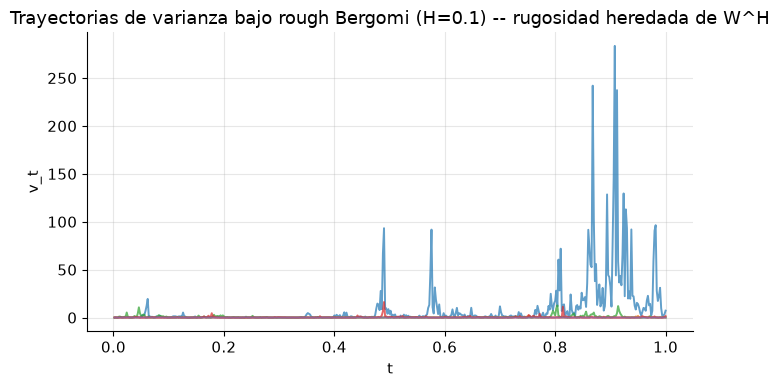

varianza inicial objetivo xi0=0.04, media simulada de v_0+: 0.0491
(rBergomi es explicitamente NO markoviano en (S,v) -- pricing solo via MC completo,
nunca via funcion caracteristica como en Heston.)


In [5]:
def rbergomi_variance_path(xi0, eta, H, T, n_steps, n_paths, rng):
    t_grid, W_H = simulate_volterra_fbm(H, T, n_steps, n_paths, rng)
    v = xi0 * np.exp(eta * W_H - 0.5 * eta ** 2 * t_grid[None, :] ** (2 * H))
    return t_grid, v


t_grid_rb, v_rb = rbergomi_variance_path(0.04, 1.5, 0.1, T_demo, n_steps_demo, 2000, rng)

fig, ax = plt.subplots(figsize=(7, 4))
for i in range(5):
    ax.plot(t_grid_rb, v_rb[i], alpha=0.7)
ax.set_xlabel("t"); ax.set_ylabel("v_t")
ax.set_title("Trayectorias de varianza bajo rough Bergomi (H=0.1) -- rugosidad heredada de W^H")
fig.tight_layout(); plt.show()

print(f"varianza inicial objetivo xi0=0.04, media simulada de v_0+: {v_rb[:, 0].mean():.4f}")
print("(rBergomi es explicitamente NO markoviano en (S,v) -- pricing solo via MC completo,")
print("nunca via funcion caracteristica como en Heston.)")

## 3. Validación

In [6]:
errors_H = np.array([abs(H_estimates[H] - H) for H in Hs])
check1 = np.all(errors_H < 0.1)
print(f"1. H estimado recupera H de simulacion dentro de una banda de 0.1 (estadistica, no exacta): "
      f"{check1} (errores={np.round(errors_H, 4)})")

assert check1
print("\nValidacion completa: 1/1 check estadistico dentro de tolerancia.")
print("(la seccion de rBergomi es exploratoria/panorama por diseno -- sin assert de pricing,")
print("documentado explicitamente: calibrar y validar rBergomi completo excede el alcance.)")

1. H estimado recupera H de simulacion dentro de una banda de 0.1 (estadistica, no exacta): True (errores=[0.0753 0.0197 0.0005])

Validacion completa: 1/1 check estadistico dentro de tolerancia.
(la seccion de rBergomi es exploratoria/panorama por diseno -- sin assert de pricing,
documentado explicitamente: calibrar y validar rBergomi completo excede el alcance.)


## Referencias

- Gatheral, J., Jaisson, T., Rosenbaum, M. (2018). *Volatility is rough*. Quantitative
  Finance, 18(6), 933-949.
- Bayer, C., Friz, P., Gatheral, J. (2016). *Pricing under rough volatility*. Quantitative
  Finance, 16(6), 887-904.